In [14]:
from scipy.io import wavfile as wav

import librosa 
import numpy as np
import pandas as pd
import os

In [15]:
filename = './archive/fold1/101415-3-0-3.wav' 

librosa_audio, librosa_sample_rate = librosa.load(filename) 
scipy_sample_rate, scipy_audio = wav.read(filename) 

print('Original sample rate:', scipy_sample_rate) 
print('Librosa sample rate:', librosa_sample_rate) 

Original sample rate: 48000
Librosa sample rate: 22050


In [16]:
print('Original audio file min~max range:', np.min(scipy_audio), 'to', np.max(scipy_audio))
print('Librosa audio file min~max range:', np.min(librosa_audio), 'to', np.max(librosa_audio))

Original audio file min~max range: -27967 to 26427
Librosa audio file min~max range: -0.8541817 to 0.8053372


In [17]:
max = 0

def extract_features(file_name):
   
    try:
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        #print(mfccs.shape) # 이거 추가해봄
        mfccsscaled = np.mean(mfccs.T,axis=0)
        global max
        if mfccs.shape[1] > max:
            max = mfccs.shape[1]
            print(max)

    except Exception as e:
        print("Error encountered while parsing file: ", file_name)
        return None 
     
    return mfccsscaled
    

In [18]:
# 데이터셋 path 지정
fulldatasetpath = './archive/fold1'

metadata = pd.read_csv('./archive/UrbanSound8K_fold1.csv')

features = []

In [19]:
# 각 소리에 대해 feature를 추출
for index, row in metadata.iterrows():
    
    file_name = os.path.join(os.path.abspath(fulldatasetpath)+'\\'+str(row["slice_file_name"]))
    
    class_label = row["class"]
    data = extract_features(file_name)
    
    features.append([data, class_label])

173


In [20]:
# df로 만들기
featuresdf = pd.DataFrame(features, columns=['feature','class_label'])

print('Finished feature extraction from ', len(featuresdf), ' files') 
print('Max_len :',max)

Finished feature extraction from  873  files
Max_len : 173


In [13]:
mfccs = librosa.feature.mfcc(y = librosa_audio, sr = librosa_sample_rate, n_mfcc = 40)
print(mfccs.shape)

NameError: name 'librosa_audio' is not defined

In [ ]:
import librosa.display
librosa.display.specshow(mfccs, sr = librosa_sample_rate, x_axis = 'time')

In [ ]:
import tensorflow as tf

In [ ]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

X = np.array(featuresdf.feature.tolist())
y = np.array(featuresdf.class_label.tolist())

le = LabelEncoder()
yy = to_categorical(le.fit_transform(y))

In [90]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, yy, test_size = 0.2, random_state = 42)

In [143]:
#CNN
# extract feature 함수 재정의
import numpy as np
max_pad_len = 173
test_num = 0

def extract_features(file_name):
    try:
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
        mfccs = librosa.feature.mfcc(y=audio, sr = sample_rate, n_mfcc = 40)
        pad_width = max_pad_len - mfccs.shape[1] #s..  .ㅎ
        mfccs = np.pad(mfccs, pad_width = ((0, 0), (0, pad_width)), mode = 'constant')
        #print(mfccs.shape)

    except Exception as e:
        print("Error 발생: ", file_name)
        print(e)
        return None

    return mfccs

In [93]:
import pandas as pd
import os
import librosa

fulldatasetpath = './archive/fold1'
metadata = pd.read_csv('./archive/UrbanSound8K_fold1.csv')
features = []

for index, row in metadata.iterrows():
    file_name = os.path.join(os.path.abspath(fulldatasetpath)+'/'+str(row["slice_file_name"]))
    class_label = row["classID"]
    data = extract_features(file_name)
    
    features.append([data, class_label])

featuresdf = pd.DataFrame(features, columns = ['feature', 'class_label'])

print('Finished feature extraction from ', len(featuresdf), ' files') 

Finished feature extraction from  873  files


In [95]:
num_rows = 40
num_columns = 173
num_channels = 1

print("train data shape")
print(x_train.shape)
print(x_test.shape)
x_train = x_train.reshape(x_train.shape[0], num_rows, num_columns, num_channels)
x_test = x_test.reshape(x_test.shape[0], num_rows, num_columns, num_channels)

print("\ntrain data reshape 결과")
print(x_train.shape)
print(x_test.shape)

train data shape
(698, 40, 173)
(175, 40, 173)

train data reshape 결과
(698, 40, 173, 1)
(175, 40, 173, 1)


In [4]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.utils import np_utils
from sklearn import metrics

num_labels = yy.shape[1]
filter_size = 2


In [110]:
#CNN모델 구현
model = Sequential()
model.add(Conv2D(filters = 16, kernel_size = 2, input_shape = (num_rows, num_columns, num_channels), activation = 'relu'))
model.add(MaxPooling2D(pool_size = 2))
model.add(Dropout(0.2))

model.add(Conv2D(filters = 32, kernel_size = 2, activation = 'relu'))
model.add(MaxPooling2D(pool_size = 2))
model.add(Dropout(0.2))

model.add(Conv2D(filters = 64, kernel_size = 2, activation = 'relu'))
model.add(MaxPooling2D(pool_size = 2))
model.add(Dropout(0.2))

model.add(Conv2D(filters = 128, kernel_size = 2, activation = 'relu'))
model.add(MaxPooling2D(pool_size = 2))
model.add(Dropout(0.2))
model.add(GlobalAveragePooling2D())

model.add(Dense(num_labels, activation = 'softmax'))



In [114]:
#컴파일
training_epochs = 30
num_batch_size = 128

learning_rate = 0.005

model.compile(loss = 'categorical_crossentropy'
				, metrics = ['accuracy']
                , optimizer = 'adam')
history = model.fit(x_train, y_train, batch_size=num_batch_size, epochs=training_epochs)            
model.summary()
score = model.evaluate(x_test, y_test, verbose = 1)
accuracy = 100 * score[1]

print('Pre-training accuracy: %.4f%%' % accuracy)

Epoch 1/30
6/6 [==============================] - 1s 219ms/step - loss: 0.9658 - accuracy: 0.6648
Epoch 2/30
6/6 [==============================] - 1s 231ms/step - loss: 0.8787 - accuracy: 0.6934
Epoch 3/30
6/6 [==============================] - 1s 217ms/step - loss: 0.7838 - accuracy: 0.7292
Epoch 4/30
6/6 [==============================] - 1s 244ms/step - loss: 0.7078 - accuracy: 0.7607
Epoch 5/30
6/6 [==============================] - 1s 242ms/step - loss: 0.6484 - accuracy: 0.7908
Epoch 6/30
6/6 [==============================] - 1s 241ms/step - loss: 0.6263 - accuracy: 0.7880
Epoch 7/30
6/6 [==============================] - 1s 231ms/step - loss: 0.5571 - accuracy: 0.8166
Epoch 8/30
6/6 [==============================] - 1s 229ms/step - loss: 0.5111 - accuracy: 0.8238
Epoch 9/30
6/6 [==============================] - 1s 249ms/step - loss: 0.4920 - accuracy: 0.8467
Epoch 10/30
6/6 [==============================] - 2s 265ms/step - loss: 0.5057 - accuracy: 0.8252
Epoch 11/30
6/6 [==

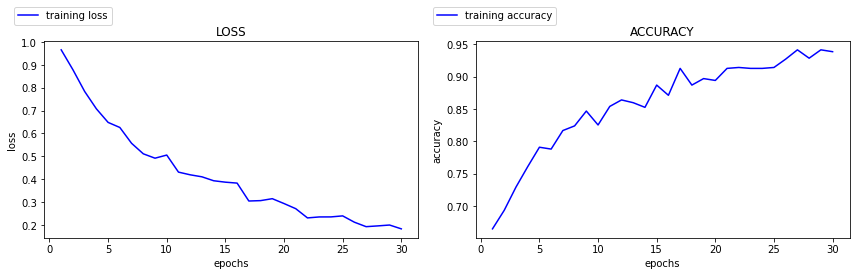

In [116]:
import matplotlib.pyplot as plt

def vis(history,name) :
    plt.title(f"{name.upper()}")
    plt.xlabel('epochs')
    plt.ylabel(f"{name.lower()}")
    value = history.history.get(name)
    val_value = history.history.get(f"val_{name}",None)
    epochs = range(1, len(value)+1)
    plt.plot(epochs, value, 'b-', label=f'training {name}')
    if val_value is not None :
        plt.plot(epochs, val_value, 'r:', label=f'validation {name}')
    plt.legend(loc='upper center', bbox_to_anchor=(0.05, 1.2) , fontsize=10 , ncol=1)

def plot_history(history) :
    key_value = list(set([i.split("val_")[-1] for i in list(history.history.keys())]))
    plt.figure(figsize=(12, 4))
    for idx , key in enumerate(key_value) :
        plt.subplot(1, len(key_value), idx+1)
        vis(history, key)
    plt.tight_layout()
    plt.show()
    
plot_history(history)

In [5]:
model.save("./soundCsf_0629.h5")

NameError: name 'model' is not defined

In [159]:
def print_prediction(file_name):
    prediction_feature = extract_features(file_name) 
    print(prediction_feature.shape)
    #num_rows = 40
    #num_columns = 173
    #num_channels = 1
    #x_train = x_train.reshape(x_train.shape[0], num_rows, num_columns, num_channels)
    prediction_feature = tf.expand_dims(prediction_feature, axis=-1)
    prediction_feature = tf.expand_dims(prediction_feature, axis=0)
    print(prediction_feature.shape)
    predicted_vector = model.predict_classes(prediction_feature)
    
    predicted_class = le.inverse_transform(predicted_vector) 
    print("The predicted class is:", predicted_class[0], '\n') 

    predicted_proba_vector = model.predict_proba(prediction_feature) 
    predicted_proba = predicted_proba_vector[0]
    for i in range(len(predicted_proba)): 
        category = le.inverse_transform(np.array([i]))
        print(category[0], "\t\t : ", format(predicted_proba[i], '.32f') )

In [169]:
filename = './archive/fold1/108362-2-0-30.wav'
print_prediction(filename) 

(40, 173)
(1, 40, 173, 1)
The predicted class is: 2 

0 		 :  0.00192954263184219598770141601562
1 		 :  0.01492144539952278137207031250000
2 		 :  0.88002419471740722656250000000000
3 		 :  0.01816644333302974700927734375000
4 		 :  0.00187554233707487583160400390625
5 		 :  0.00085838086670264601707458496094
6 		 :  0.00002388646134932059794664382935
7 		 :  0.00117013987619429826736450195312
8 		 :  0.05108341947197914123535156250000
9 		 :  0.02994697540998458862304687500000
